# Model Failure Analysis

Out-of-fold residual diagnostics for the final XGBoost model: where it mispredicts by price level and by community area. Uses 5-fold cross-validation so every sale is predicted by a model that never saw it (**~5x the runtime of a single fit**). Sign convention: error = predicted − actual, so positive = overprediction.

In [1]:
import json
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error

# same data prep as Tree_Model.ipynb
data = pd.read_parquet(r"..\Data\sale_and_crime_data\chicago_sales_with_crime.parquet")
features_to_exclude = ["pin","is_multisale",'flood_fema_sfha', "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 'pin10', 'nearest_metra_route_dist_ft', 'nearest_new_construction_pin10',
                       "school_elementary_district_name",'nearest_golf_course_dist_ft', "school_secondary_district_name", "township_code",  "neighborhood_code",'sale_filter_deed_type', 'nearest_cta_route_dist_ft',
                                 'nearest_vacant_land_pin10','airport_noise_dnl','attic_finish','census_acs5_tract_geoid', 'nearest_neighbor_1_pin10','nearest_neighbor_2_pin10','nearest_neighbor_3_pin10','sale_date_parsed','sale_date', 'sale_year']
data = data.drop(columns=features_to_exclude)
for col in ["type_of_residence", "construction_quality", "garage_size", "basement_type",
            "ext_wall_material", "repair_condition", "basement_finish",
            "central_heating", "central_air", "community_area"]:
    data[col] = data[col].astype("category")

y = data["sale_price"]
X = data.drop(columns=["sale_price"])
with open("hyperparameters.json") as f:
    hyperparams = json.load(f)

In [2]:
# Chicago's 77 community areas in official numeric order (code 1 -> Rogers_Park, ...)
_CA = ("Rogers_Park West_Ridge Uptown Lincoln_Square North_Center Lake_View Lincoln_Park "
       "Near_North_Side Edison_Park Norwood_Park Jefferson_Park Forest_Glen North_Park "
       "Albany_Park Portage_Park Irving_Park Dunning Montclare Belmont_Cragin Hermosa "
       "Avondale Logan_Square Humboldt_Park West_Town Austin West_Garfield_Park "
       "East_Garfield_Park Near_West_Side North_Lawndale South_Lawndale Lower_West_Side "
       "Loop Near_South_Side Armour_Square Douglas Oakland Fuller_Park Grand_Boulevard "
       "Kenwood Washington_Park Hyde_Park Woodlawn South_Shore Chatham Avalon_Park "
       "South_Chicago Burnside Calumet_Heights Roseland Pullman South_Deering East_Side "
       "West_Pullman Riverdale Hegewisch Garfield_Ridge Archer_Heights Brighton_Park "
       "McKinley_Park Bridgeport New_City West_Elsdon Gage_Park Clearing West_Lawn "
       "Chicago_Lawn West_Englewood Englewood Greater_Grand_Crossing Ashburn Auburn_Gresham "
       "Beverly Washington_Heights Mount_Greenwood Morgan_Park OHare Edgewater").split()
assert len(_CA) == 77
COMMUNITY_AREA_NAMES = dict(enumerate(_CA, start=1))

def area_name(code):
    """Name for a community area code given as int, float, or string; echoes unknown codes."""
    try:
        return COMMUNITY_AREA_NAMES[int(float(code))]
    except (KeyError, ValueError, TypeError):
        return str(code)

In [3]:
cv_model = xgb.XGBRegressor(random_state=42, enable_categorical=True, tree_method="hist", **hyperparams)
oof = cross_val_predict(cv_model, X, y, cv=KFold(5, shuffle=True, random_state=42))

res = pd.DataFrame({"actual": y, "pred": oof, "area": X["community_area"].map(area_name)})
res["pct_err"] = (res["pred"] - res["actual"]) / res["actual"]   # positive = overprediction

print(f"5-fold CV:  R² {r2_score(res.actual, res.pred):.4f}   "
      f"MAE ${mean_absolute_error(res.actual, res.pred):,.0f}   "
      f"median |rel err| {res.pct_err.abs().median():.1%}")

5-fold CV:  R² 0.8820   MAE $85,746   median |rel err| 19.3%


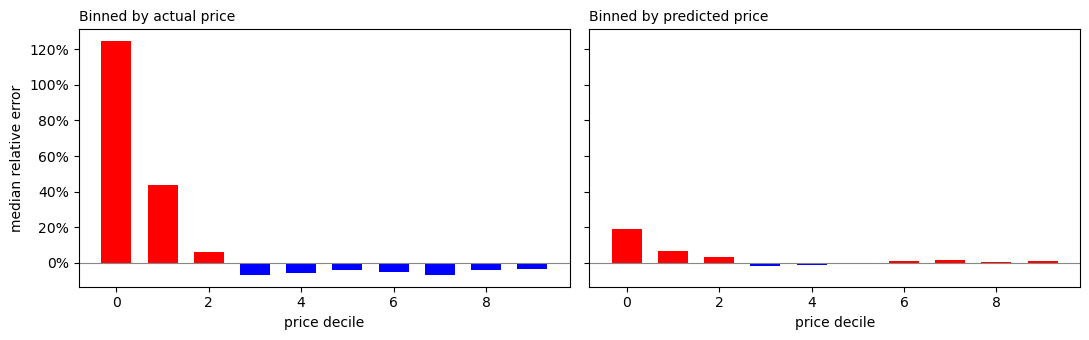

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, col, title in ((axes[0], "actual", "Binned by actual price"),
                       (axes[1], "pred", "Binned by predicted price")):
    med = res.groupby(pd.qcut(res[col], 10, labels=False), observed=True)["pct_err"].median()
    ax.bar(med.index, med, color=['r' if v > 0 else 'b' for v in med], width=0.65)
    ax.axhline(0, color=MUTED, linewidth=0.8)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("price decile")
axes[0].set_ylabel("median relative error")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

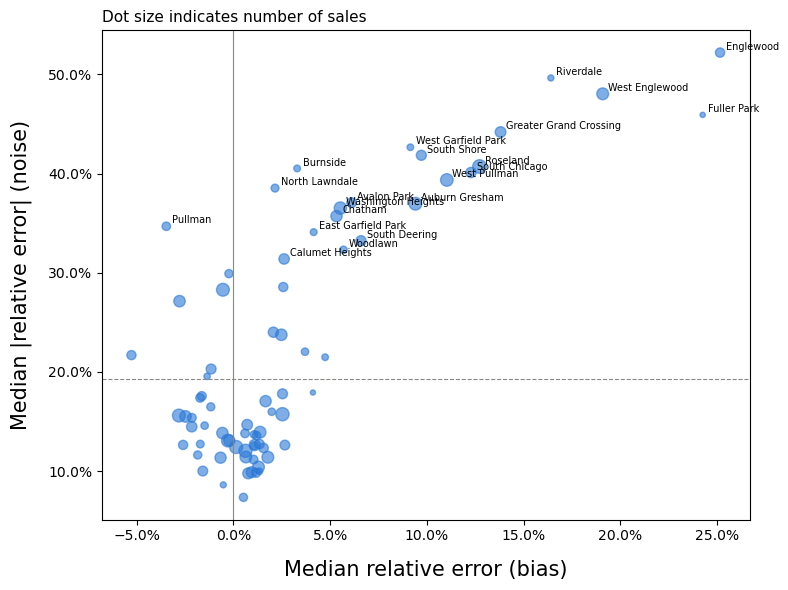

In [ ]:
by_area = res.groupby("area")["pct_err"].agg(
    n="size", bias="median", noise=lambda e: e.abs().median()).query("n >= 30")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(by_area["bias"], by_area["noise"], s=np.sqrt(by_area["n"]) * 2, color=BLUE, alpha=0.6)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.axhline(res["pct_err"].abs().median(), color=MUTED, linewidth=0.8, linestyle="--")
for a, r in by_area[(by_area["noise"] > 0.3) | (by_area["bias"].abs() > 0.1)].iterrows():
    ax.annotate(a.replace("_", " "), (r["bias"], r["noise"]), fontsize=7,
                xytext=(4, 2), textcoords="offset points")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Median relative error (bias)", labelpad=12, fontsize = 15)
ax.set_ylabel("Median |relative error| (noise)", labelpad=12, fontsize = 15)
ax.set_title("Cirle size indicates number of sales", loc="left", fontsize=11)
plt.tight_layout()
plt.show()